## Useful functions

You don't need to change these functions, and you don't have to necessarilty use them to complete your assignment. 

In [5]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, precision_score

# plot one or more features (using separate plots) for a start and end date, if y is set then it shows the anomalies
#  (could be predicted or real if ground truth used)
def plot_features(df, start_day, start_year, end_day, end_year, features, y=None):
    # Filter the period
    mask = (
        (df['year'] > start_year) | 
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) | 
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    df_period = df_period.reset_index(drop=False)  # Keep original indices for mapping y
    df_period['date'] = pd.to_datetime(
        df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')

    if isinstance(features, str):
        features = [features]

    for feature in features:
        plt.figure(figsize=(10, 4))
        plt.plot(df_period['date'], df_period[feature], marker='o', linestyle='-')

        # If y is provided, plot anomalies
        if y is not None:
            anomaly_indices = df_period[df_period['index'].map(lambda idx: y[idx] == -1)].index
            plt.scatter(
                df_period.loc[anomaly_indices, 'date'],
                df_period.loc[anomaly_indices, feature],
                color='red', marker='x', s=100, label='Anomaly'
            )
            plt.legend()

        plt.title(f'{feature} over time')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# show a summary of the dataset, not crucial, but useful to understand the data
def print_summary(y_true):
    total = len(y_true)
    n_anomalies = (y_true == -1).sum()
    n_normals = (y_true == 1).sum()

    print("Dataset Summary:")
    print(f"Total instances:         {total}")
    print(f"Normal instances (1):    {n_normals}")
    print(f"Anomalous instances (-1): {n_anomalies}")
    print(f"Anomaly ratio:           {n_anomalies / total:.3%}")

# plot detections, useful when you already have the predictions and want to observe then on the data for each feature
def plot_detection(df, y_true, y_pred, start_day, start_year, end_day, end_year, feature):
    mask = (
        (df['year'] > start_year) | 
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) | 
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    idx_period = df_period.index
    df_period['date'] = pd.to_datetime(
    df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')
    y_true_period = y_true[idx_period]
    y_pred_period = y_pred[idx_period]

    correct = (y_true_period == -1) &  (y_pred_period == -1)
    missed = (y_true_period == -1) & (y_pred_period != -1)
    false_pos = (y_true_period != -1) & (y_pred_period == -1)

    plt.figure(figsize=(10, 4))
    plt.plot(df_period['date'], df_period[feature], label=feature, color='blue', linestyle='-')
    plt.scatter(df_period.loc[correct, 'date'], df_period.loc[correct, feature], 
                marker='x', color='green', label='Correct Anomaly')
    plt.scatter(df_period.loc[missed, 'date'], df_period.loc[missed, feature], 
                marker='x', color='red', label='Missed Anomaly')
    plt.scatter(df_period.loc[false_pos, 'date'], df_period.loc[false_pos, feature], 
                marker='x', color='orange', label='False Positive')

    plt.title(f'{feature} with Detected Anomalies')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# to facilitate the visualization of the results for the anomaly detection methods in part 1
def evaluate_predictions(y_true, y_pred, model_name="unnamed", header=True):
    # convert from -1 to 1 (1 for anomaly, 0 for normal) for evaluating
    y_true_binary = (y_true == -1).astype(int)
    y_pred_binary = (y_pred == -1).astype(int)

    recall = recall_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary)

    correct = (y_true == -1) & (y_pred == -1)
    missed = (y_true == -1) & (y_pred != -1)
    false_positives = (y_true != -1) & (y_pred == -1)

    if header:
        print("| Model | Recall | Precision | Correct | Missed | False Positives |")
        print("|-------|--------|-----------|---------|--------|------------------|")
    
    print(f"| {model_name} | {recall:.3f} | {precision:.3f} | {correct.sum()} | {missed.sum()} | {false_positives.sum()} |")

## Example: reading and visualizing the data

In [6]:
import os
import pandas as pd

# Loading the data. y2122 contains the 'labels'
df2122 = None
y2122 = None

# Check and load if files exist
if os.path.exists("GenSyn2122.csv") and os.path.exists("GenSyn_labels2122.csv"):
    print("Loading GenSyn2122 dataset...")
    df2122 = pd.read_csv("GenSyn2122.csv")
    # -1 = anomaly, 1 = normal
    y2122 = pd.read_csv("GenSyn_labels2122.csv")['anomaly_label'].values

# Visualise part of the data...
# plot_features(df2122, 1, 2021, 100, 2021, ['temperature','energy_usage', 'season'])
display(df2122)

Loading GenSyn2122 dataset...


,year,day_of_year,season,temperature,humidity,energy_usage
0,2021,1,summer,19.708638,78.625889,11.731837
1,2021,2,summer,20.703554,78.350411,13.453957
2,2021,3,summer,21.339178,82.736788,15.393096
3,2021,4,summer,20.823304,79.921728,16.657684
4,2021,5,summer,22.277698,80.406175,16.927320
...,...,...,...,...,...,...
725,2022,361,summer,24.648768,79.422802,18.579817
726,2022,362,summer,24.362897,80.541095,19.394421
727,2022,363,summer,24.730546,85.748327,20.060006
728,2022,364,summer,26.975549,81.506959,20.840548


### Example: Using function evaluate_predictions

In [7]:
# evaluate_predictions(y_true=y2122, y_pred=the predictions of your model, model_name="name of the model", header=True):
# for example, if we use the ground truth to evaluate. You can past the result on a markdown cell to get a nice looking table
evaluate_predictions(y_true=y2122, y_pred=y2122, model_name="example", header=True)

| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| example | 1.000 | 1.000 | 18 | 0 | 0 |


### Example: plotting anomalies using plot_detection

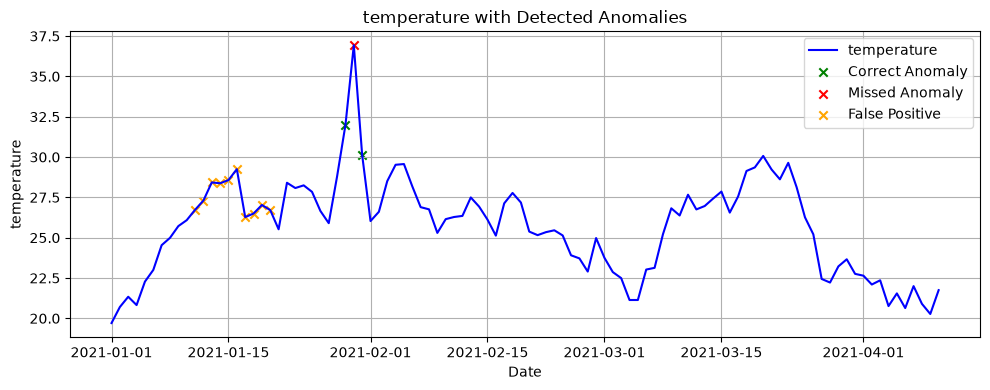

In [8]:
# generating some fake predictions for the plot
fake_preds=y2122.copy()
fake_preds[10:20] = -1
fake_preds[29] = 1
plot_detection(df=df2122, y_true=y2122, y_pred=fake_preds, start_day=1, start_year=2021, end_day=100, end_year=2021, feature="temperature")

### Example: using function plot_features

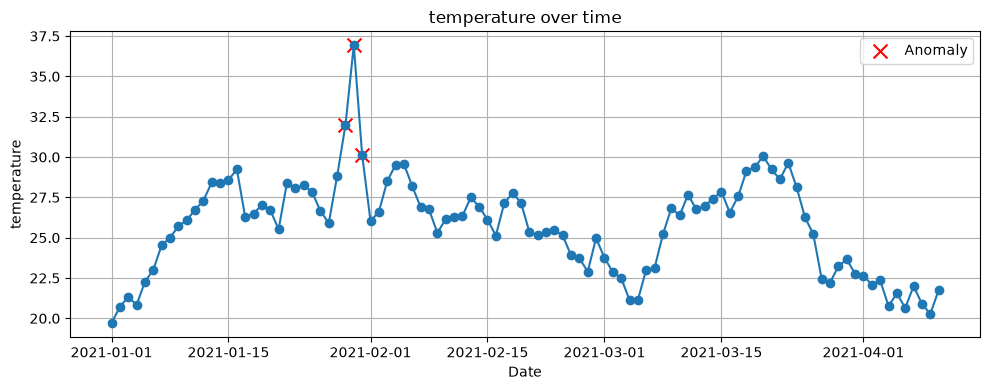

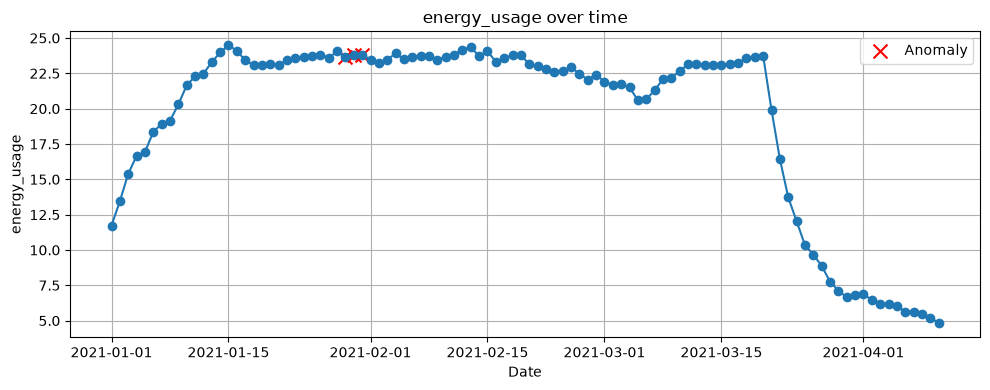

In [9]:
plot_features(df=df2122, y=y2122, start_day=1, start_year=2021, end_day=100, end_year=2021, features=["temperature", "energy_usage"])

### Statistics about the anomalies

In [10]:
print_summary(y2122)

Dataset Summary:
Total instances:         730
Normal instances (1):    712
Anomalous instances (-1): 18
Anomaly ratio:           2.466%


# Part 1: Anomaly detection
## <span style="color: red; font-weight: 700;">Your answers should start here!</span>

Use the provided functions to help you, if you want to code your own plotting functions, feel free to do so, but make sure the metrics calculation is correct!

## a)

In [11]:
import numpy as np

# prepare the data for the anomaly detection methods 
df = df2122.copy()

# one hot encoding of the season feature, we can also use other encoding methods, but this is a common one for categorical features
df = pd.get_dummies(df, columns=['season'], drop_first=True)

# create cyclic features for the timestamp, this is a common technique to capture the periodicity of time-based data, especially when dealing with seasonal patterns
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

# drop the original day_of_year column as we have already captured its information in the cyclic features 
df = df.drop(['day_of_year'], axis=1) 


# X will be the input for the anomaly detection methods, it contains all the features after preprocessing
X = df.values

display(df)


,year,temperature,humidity,energy_usage,season_spring,season_summer,season_winter,day_sin,day_cos
0,2021,19.708638,78.625889,11.731837,False,True,False,1.721336e-02,0.999852
1,2021,20.703554,78.350411,13.453957,False,True,False,3.442161e-02,0.999407
2,2021,21.339178,82.736788,15.393096,False,True,False,5.161967e-02,0.998667
3,2021,20.823304,79.921728,16.657684,False,True,False,6.880243e-02,0.997630
4,2021,22.277698,80.406175,16.927320,False,True,False,8.596480e-02,0.996298
...,...,...,...,...,...,...,...,...,...
725,2022,24.648768,79.422802,18.579817,False,True,False,-6.880243e-02,0.997630
726,2022,24.362897,80.541095,19.394421,False,True,False,-5.161967e-02,0.998667
727,2022,24.730546,85.748327,20.060006,False,True,False,-3.442161e-02,0.999407
728,2022,26.975549,81.506959,20.840548,False,True,False,-1.721336e-02,0.999852


## b)

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

#IF
if_def = IsolationForest(random_state=42)
y_if_def = if_def.fit_predict(X)

# LOF
lof_def = LocalOutlierFactor()
y_lof_def = lof_def.fit_predict(X)

# evaluate the predictions of the default models
print("--------------Default Isolation Forest-----------")
evaluate_predictions(y2122, y_if_def, "IF")

print("--------------Default LOF------------------------")
evaluate_predictions(y2122, y_lof_def, "LOF")



--------------Default Isolation Forest-----------
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF | 0.944 | 0.047 | 17 | 1 | 348 |
--------------Default LOF------------------------
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| LOF | 0.444 | 0.276 | 8 | 10 | 21 |


# Answer
- Which model had higher recall? Which had higher precision?
IF has higher recall than LOF and LOF has higher precision than IF.
- What do these differences suggest about how each algorithm works?
IF works by isolating anomalies through random feature splits, making it effective at identifying global anomalies that are far from normal data. LOF measures local density differences, so it excels at detecting local anomalies within clusters rather than only isolated points.
- In which situations would one be preferred over the other?
IF is preferred for detecting global anomalies.LOF is preferred for detecting local anomalies.


## c)

In [13]:
contamination_list = [0.03, 0.1]

#IF 
for cont in contamination_list:
    print(f"\n---------------------- IF contamination={cont}----------------------")
    for n_est in [100, 200, 300]:
        model = IsolationForest(contamination=cont, n_estimators=n_est, random_state=42)
        y_pred = model.fit_predict(X)
        evaluate_predictions(y2122, y_pred, f"IF(n_est={n_est})", header=(n_est==100))

#LOF 
for cont in contamination_list:
    print(f"\n  ---------------------- LOF contamination={cont}----------------------")
    for n_neigh in [10, 30, 60]:
        model = LocalOutlierFactor(contamination=cont, n_neighbors=n_neigh)
        y_pred = model.fit_predict(X)
        evaluate_predictions(y2122, y_pred, f"LOF(n_neigh={n_neigh})", header=(n_neigh==10))


---------------------- IF contamination=0.03----------------------
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF(n_est=100) | 0.278 | 0.227 | 5 | 13 | 17 |
| IF(n_est=200) | 0.222 | 0.182 | 4 | 14 | 18 |
| IF(n_est=300) | 0.222 | 0.182 | 4 | 14 | 18 |

---------------------- IF contamination=0.1----------------------
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF(n_est=100) | 0.556 | 0.137 | 10 | 8 | 63 |
| IF(n_est=200) | 0.611 | 0.151 | 11 | 7 | 62 |
| IF(n_est=300) | 0.667 | 0.164 | 12 | 6 | 61 |

  ---------------------- LOF contamination=0.03----------------------
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| LOF(n_neigh=10) | 0.444 | 0.364 | 8 | 10 | 14 |
| LOF(n_neigh=30) | 0.278 | 0.227 | 5 | 13 | 

# (c) Hyperparameter Tuning Results

## IF (cont=0.03) Results
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF(n_est=100) | 0.278 | 0.227 | 5 | 13 | 17 |
| IF(n_est=200)| 0.222 | 0.182 | 4 | 14 | 18 |
| IF(n_est=300)| 0.222 | 0.182 | 4 | 14 | 18 | 
## IF (cont=0.1) Results
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF(n_est=100)| 0.556 | 0.137 | 10 | 8 | 63 |
| IF(n_est=200) | 0.611 | 0.151 | 11 | 7 | 62 |
| IF(n_est=300) | 0.667 | 0.164 | 12 | 6 | 61 |

## LOF (cont=0.03) Results
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| LOF(n_neigh=10) | 0.444 | 0.364 | 8 | 10 | 14 |
| LOF(n_neigh=30) | 0.278 | 0.227 | 5 | 13 | 17 |
| LOF(n_neigh=60)| 0.389 | 0.318 | 7 | 11 | 15 |

## LOF (cont=0.1)  Results

| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| LOF(n_neigh=10) | 0.611 | 0.151 | 11 | 7 | 62 |
| LOF(n_neigh=30) | 0.611 | 0.151 | 11 | 7 | 62 |
| LOF(n_neigh=60) | 0.556 | 0.137 | 10 | 8 | 63 |

## d)

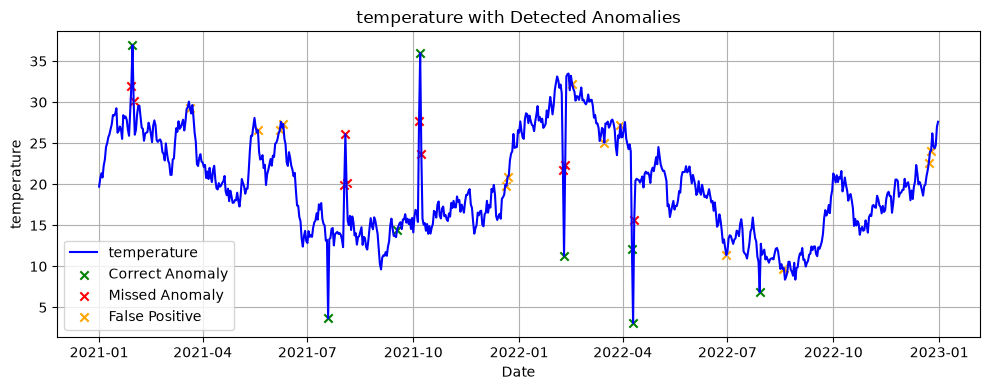

In [14]:
best_model = LocalOutlierFactor(contamination=0.03, n_neighbors=10)
y_best = best_model.fit_predict(X)
 
plot_detection(
    df=df2122,
    y_true=y2122,
    y_pred=y_best,
    start_day=1,
    start_year=2021,
    end_day=365,
    end_year=2022,
    feature="temperature"
)

1. Selected Model: 
Local Outlier Factor (LOF) with contamination=0.03 and n_neighbors=10
2. Justification: 
I selected this model because it provides the best trade‑off between recall and precision. It achieves the highest precision (0.364) among all tested models, which means it produces far fewer false positives (only 14). Although recall (0.444) is not the absolute highest, the low false alarm rate makes this model much more reliable and practical for anomaly detection. 
3. Analyse the results: 
There are clear false positives. Most false positives are at rapidly rising or rapidly descent. For example, the temperature around 2022-01, 2022-12 are incorrectly flagged as anomalies. 
The detected anomalies are contextual anomalies. The LOF model identifies points that deviate from their local neighbourhood. Some global anomalies are detected, but only when they also significantly differ from nearby values.
Other globally extreme points were missed because they did not differ enough from their immediate surroundings, such as temperature around 2021-08 and 2021-02.


## e) (AIML420 mandatory) 

| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF+LOF Ensemble | 0.556 | 0.312 | 10 | 8 | 22 |


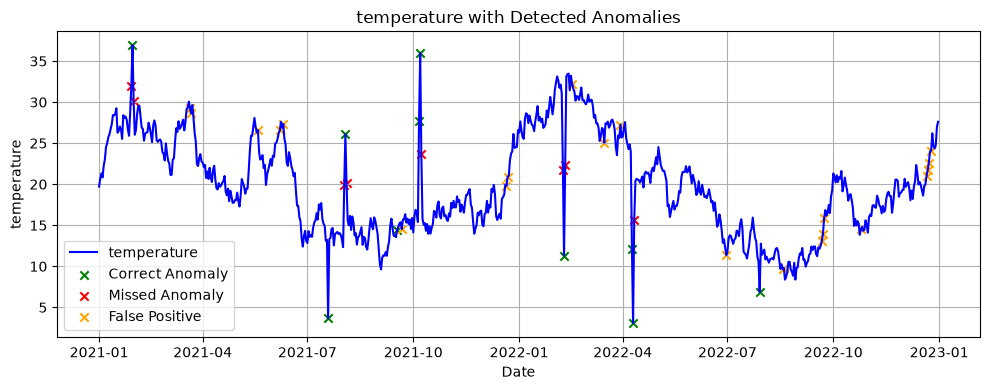

In [15]:
# training two models for the ensemble method, you can choose the parameters based on the previous results, here we just use some of them as an example
if_model = IsolationForest(contamination=0.03, n_estimators=100, random_state=42)
lof_model = LocalOutlierFactor(contamination=0.03, n_neighbors=10)

y_if = if_model.fit_predict(X)
y_lof = lof_model.fit_predict(X)
 
# y_ensemble = np.where((y_if == -1) & (y_lof == -1), -1, 1)
y_ensemble = np.where((y_if == -1) | (y_lof == -1), -1, 1)
 
evaluate_predictions(y2122, y_ensemble, "IF+LOF Ensemble")

plot_detection(
    df=df2122,
    y_true=y2122,
    y_pred=y_ensemble,
    start_day=1,
    start_year=2021,
    end_day=365,
    end_year=2022,
    feature="temperature"
)

# plot_features(
#     df=df2122,
#     y=y2122,
#     start_day=1,
#     start_year=2021,
#     end_day=365,
#     end_year=2022,
#     features=["temperature", "energy_usage"]
# )

# print_summary(y2122)


# (e) Exploring Alternative Approaches (AIML420 mandatory) (20% AIML420)
I combined IF(contamination=0.03, n_estimators=100) and LOF(contamination=0.03, n_neighbors=10) into an ensemble model, and this ensemble can combine IF’s strength in global anomaly detection and LOF’s strength in local anomaly detection, aiming to catch more true anomalies without excessive false positives.

Then I used an OR voting ensemble: if either model flags a point as an anomaly, it is classified as an anomaly. This maximizes recall at the cost of some precision.`y_ensemble = np.where((y_if == -1) | (y_lof == -1), -1, 1)`
## Results
| Model | Recall | Precision | Correct | Missed | False Positives |
|-------|--------|-----------|---------|--------|------------------|
| IF+LOF Ensemble | 0.556 | 0.312 | 10 | 8 | 22 |
## Discussion
Looking at the results, I think the method worked well. The ensemble shows a significant increase in recall with only a small drop in precision.

Compared with the result of LOF(contamination=0.03, n_neighbors=10) from last part, the ensemble increases the recall from 0.444 to 0.556 and decrease the precision from 0.364 to 0.312. 
And compared with the result of IF(contamination=0.03, n_estimators=100) from last part, the ensemble significantly improves the recall from 0.278 to 0.556 and improves the precision from 0.227 to 0.312.

Overall, this ensemble effectively balances the strengths of both models:  IF helps capture more global anomalies, and LOF retains strong precision, resulting in fewer false positives than IF alone.

This shows that combining models can create a more reliable detector than using either method alone.
